## Plot 1 : Env02b: Entropy versus Layer

Graphique finalisé sauvegardé sous : E3_entropy_final_report.png


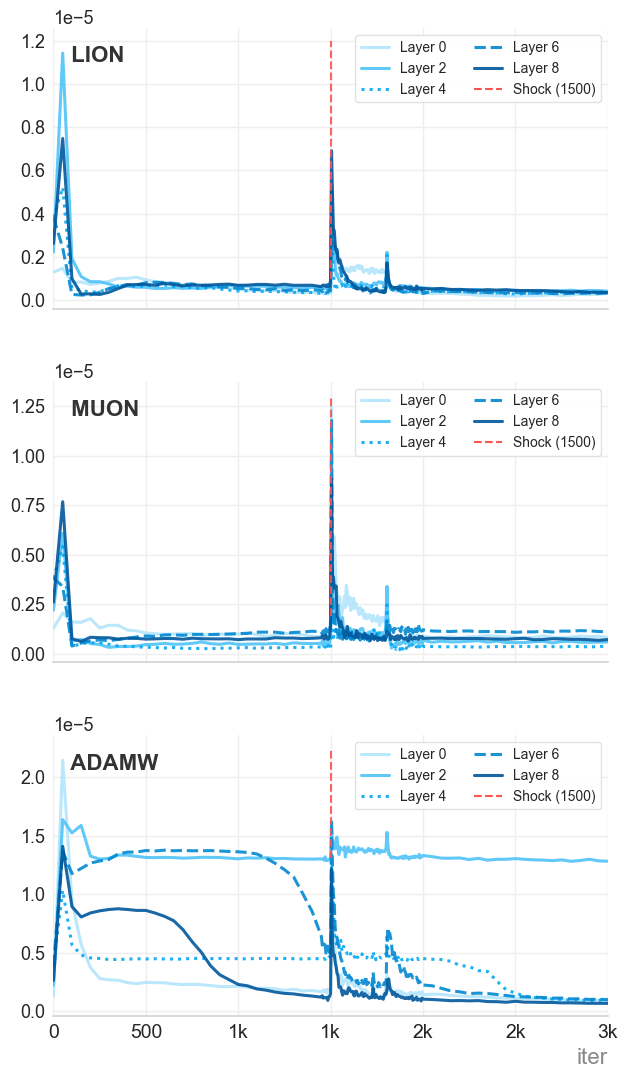

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.size": 14,                # Augmenté globalement (12 -> 14)
        "axes.labelsize": 16,           # Augmenté (13 -> 16)
        "axes.titlesize": 18,           # Augmenté (14 -> 18)
        "xtick.labelsize": 14,          # Augmenté (11 -> 14)
        "ytick.labelsize": 13,          # Augmenté (10 -> 13)
        "grid.color": "#EEEEEE",      
        "axes.edgecolor": "#FFFFFF",   
    }
)

# Palette de couleurs d'origine
LAYER_COLORS = {
    0: "#B3E5FC",  
    2: "#4FC3F7",  
    4: "#03A9F4",  
    6: "#0288D1",  
    8: "#01579B",  
}

# Styles de ligne
LAYER_STYLES = {
    0: "-",       
    2: "-",       
    4: ":",       
    6: "--",      
    8: "-",       
}

SHOCK_ITER = 1500

def plot_e3_entropy_final(dossier_data, nom_fichier_sortie):
    layers = [0, 2, 4, 6, 8]
    optimizers = ["lion", "muon", "adamw"]
    
    # Largeur compacte 6.5 et hauteur 11 pour accueillir confortablement les textes agrandis
    fig, axes = plt.subplots(len(optimizers), 1, figsize=(6.5, 11), sharex=True)
    
    data_dict = {opt: {} for opt in optimizers}
    
    # 1. Lecture et centralisation des données
    for layer in layers:
        csv_path = os.path.join(dossier_data, f"E3_entropy_layer{layer}.csv")
        if not os.path.exists(csv_path):
            print(f"Attention : Fichier manquant {csv_path}")
            continue
            
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        
        x_col = "iter"
        metric_substring = f"router/layer_{layer}/entropy"
        
        if x_col not in df.columns:
            continue

        for col in df.columns:
            if metric_substring in col and not (col.endswith("__MIN") or col.endswith("__MAX")):
                run_name = col.split(" - ")[0] if " - " in col else col
                clean_label = run_name.replace("env3_", "").replace("env2_", "").replace("env1_", "")
                clean_label = clean_label.split("_2026")[0].split("_shock")[0].split("_1500")[0]
                
                if clean_label in optimizers:
                    plot_data = df[[x_col, col]].dropna()
                    if not plot_data.empty:
                        data_dict[clean_label][layer] = (plot_data[x_col], plot_data[col])

    # 2. Construction des graphiques par optimiseur
    for i, opt in enumerate(optimizers):
        ax = axes[i]
        
        # --- TITRE DE L'OPTIMISEUR TRÈS GRAND ---
        ax.text(0.02, 0.90, f" {opt.upper()}", transform=ax.transAxes, 
                fontsize=16, fontweight='bold', color='#333333', ha='left', va='center')
        
        max_y_at_shock = -np.inf  # Initialisation pour capturer le sommet des courbes au Shock

        # Tracer chaque layer avec son style et sa couleur
        for layer in layers:
            if layer in data_dict[opt]:
                x_vals, y_vals = data_dict[opt][layer]
                
                # Extraction de la valeur de cette courbe au moment du shock (1500)
                val_at_shock = y_vals[x_vals == SHOCK_ITER].values
                if val_at_shock.size > 0:
                    max_y_at_shock = max(max_y_at_shock, val_at_shock[0])

                ax.plot(
                    x_vals,
                    y_vals,
                    label=f"Layer {layer}", 
                    color=LAYER_COLORS[layer],
                    linestyle=LAYER_STYLES[layer],
                    linewidth=2.2, # Légèrement épaissi pour suivre la taille des polices
                    alpha=0.9
                )
        
        # --- MARQUE DU SHOCK LOCALISÉE ET AÉRÉE ---
        if max_y_at_shock != -np.inf:
            curr_ylim = ax.get_ylim()
            # On part du haut de la plus haute courbe jusqu'au plafond du subplot
            ax.vlines(x=SHOCK_ITER, ymin=max_y_at_shock, ymax=curr_ylim[1],
                      color="#FF5252", linestyle="--", linewidth=1.5, alpha=0.9)
        else:
            # Fallback standard si l'itération exacte n'est pas indexée
            ax.axvline(x=SHOCK_ITER, color="#FF5252", linestyle="--", linewidth=1.5, alpha=0.9)

        # Ajout manuel du Shock dans la légende
        ax.plot([], [], color="#FF5252", linestyle="--", linewidth=1.5, label="Shock (1500)")
        
        # --- LOOK & FEEL ---
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=False)
        ax.spines['bottom'].set_color('#D3D3D3')
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(axis='both', which='both', length=0, pad=6)
        ax.yaxis.get_major_formatter().set_powerlimits((0, 0))
        
        # --- LÉGENDE LOCALE COMPACTE (POLICE AUGMENTÉE) ---
        ax.legend(
            loc="upper right", 
            frameon=True, 
            facecolor='#FFFFFF', 
            edgecolor='#E0E0E0',
            framealpha=0.95,
            fontsize=10, # Augmenté (9 -> 11)
            ncol=2 
        )

    # --- CONFIGURATION DE L'AXE X DE FIN ---
    ax_last = axes[-1]
    ax_last.set_xlabel("iter", loc="right", color="#888888")
    ax_last.set_xlim(0, 3000)
    ax_last.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, loc: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )
    
    # Ajustements d'espacements verticaux légèrement augmentés pour éviter les chevauchements de grands textes
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.26) 
    
    plt.savefig(nom_fichier_sortie, dpi=300)
    print(f"Graphique finalisé sauvegardé sous : {nom_fichier_sortie}")
    plt.show()

# --- EXÉCUTION ---
if __name__ == "__main__":
    dossier_des_csv = "./EMA"  
    nom_image_sortie = "E3_entropy_final_report.png"
    
    plot_e3_entropy_final(dossier_des_csv, nom_image_sortie)

## Plot 2 : Env02b: Dead experts among layers

Graphique des Dead Experts sauvegardé sous : E3_dead_experts_report.png


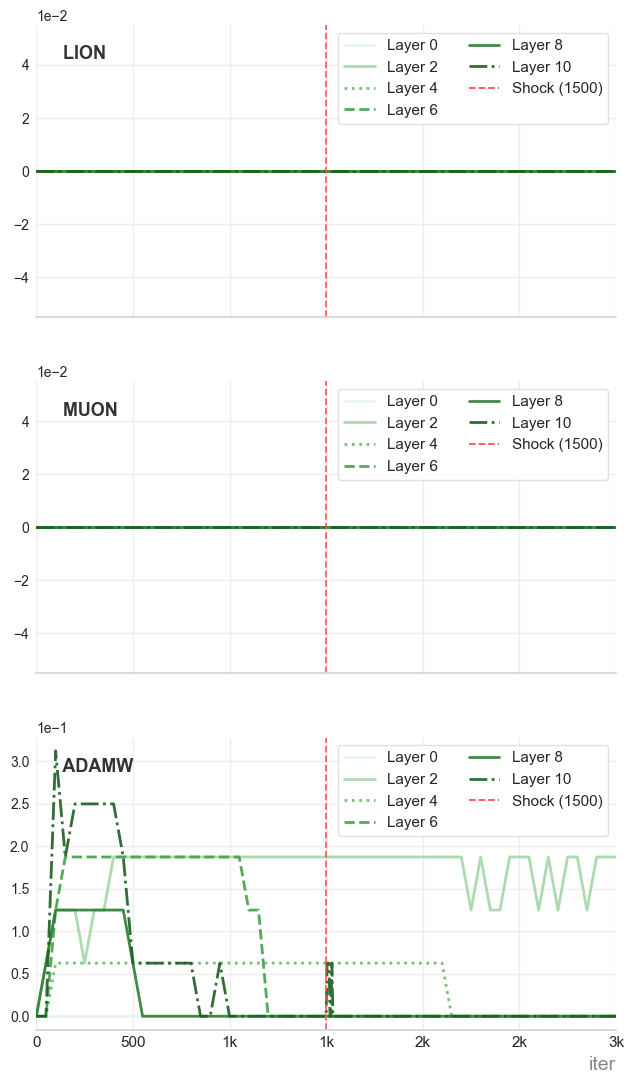

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- CONFIGURATION DU STYLE GRAPHIQUE ---
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "grid.color": "#EEEEEE",      # Style minimaliste W&B
        "axes.edgecolor": "#FFFFFF",   # Supprime les bordures extérieures
    }
)

# Nouvelle palette de déclinaisons de VERT (du plus clair au plus foncé)
LAYER_COLORS_GREEN = {
    0: "#E8F5E9",  # Vert menthe très clair
    2: "#A5D6A7",  # Vert clair
    4: "#66BB6A",  # Vert intermédiaire
    6: "#43A047",  # Vert soutenu
    8: "#2E7D32",  # Vert foncé
    10: "#1B5E20", # Vert bouteille très profond
}

# Styles de ligne inchangés pour conserver les repères visuels
LAYER_STYLES = {
    0: "-",        # Continu
    2: "-",        # Continu
    4: ":",        # Dotted (Points)
    6: "--",       # Dashed (Tirets)
    8: "-",        # Continu
    10: "-.",      # Trait-point pour le nouveau layer
}

def plot_e3_dead_experts(dossier_data, nom_fichier_sortie):
    # Ajout du Layer 10 détecté dans vos nouveaux fichiers
    layers = [0, 2, 4, 6, 8, 10]
    optimizers = ["lion", "muon", "adamw"]
    
    # Configuration du layout multi-subplots compact
    fig, axes = plt.subplots(len(optimizers), 1, figsize=(6.5, 11), sharex=True)
    
    data_dict = {opt: {} for opt in optimizers}
    
    # 1. Lecture et centralisation des données
    for layer in layers:
        csv_path = os.path.join(dossier_data, f"E3_deadexpert_layer{layer}.csv")
        if not os.path.exists(csv_path):
            print(f"Attention : Fichier manquant {csv_path}")
            continue
            
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        
        x_col = "iter"
        # Mise à jour avec votre nouvelle chaîne de caractères de métrique
        metric_substring = f"router/layer_{layer}/dead_experts"
        
        if x_col not in df.columns:
            continue

        for col in df.columns:
            if metric_substring in col and not (col.endswith("__MIN") or col.endswith("__MAX")):
                # Nettoyage et extraction de l'optimiseur
                run_name = col.split(" - ")[0] if " - " in col else col
                clean_label = run_name.replace("env3_", "").replace("env2_", "").replace("env1_", "")
                clean_label = clean_label.split("_2026")[0].split("_shock")[0].split("_1500")[0]
                
                if clean_label in optimizers:
                    plot_data = df[[x_col, col]].dropna()
                    if not plot_data.empty:
                        data_dict[clean_label][layer] = (plot_data[x_col], plot_data[col])

    # 2. Dessin des courbes par bloc d'optimiseur
    for i, opt in enumerate(optimizers):
        ax = axes[i]
        
        # Titre du bloc (ex: Optimizer: LION)
        ax.text(0.02, 0.90, f"   {opt.upper()}", transform=ax.transAxes, 
                fontsize=13, fontweight='bold', color='#333333', ha='left', va='center')
        
        # Tracé des couches avec la charte verte
        for layer in layers:
            if layer in data_dict[opt]:
                x_vals, y_vals = data_dict[opt][layer]
                ax.plot(
                    x_vals,
                    y_vals,
                    label=f"Layer {layer}", # Formatage propre demandé
                    color=LAYER_COLORS_GREEN[layer],
                    linestyle=LAYER_STYLES[layer],
                    linewidth=2.0,
                    alpha=0.9
                )
        
        # Ligne de choc rouge et repère associé dans la boîte
        ax.axvline(x=1500, color="#FF5252", linestyle="--", linewidth=1.3, alpha=0.9)
        ax.plot([], [], color="#FF5252", linestyle="--", linewidth=1.3, label="Shock (1500)")
        
        # --- LOOK & FEEL ---
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=False)
        ax.spines['bottom'].set_color('#D3D3D3')
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(axis='both', which='both', length=0, pad=5)
        ax.yaxis.get_major_formatter().set_powerlimits((0, 0))
        
        # --- LÉGENDE EN BOÎTE EN HAUT À DROITE ---
        ax.legend(
            loc="upper right", 
            frameon=True, 
            facecolor='#FFFFFF', 
            edgecolor='#E0E0E0',
            framealpha=0.95,
            fontsize=11,
            ncol=2 # Aligné sur 2 colonnes pour rester très compact verticalement
        )

    # --- CONFIGURATION DE L'AXE X GLOBAL ---
    ax_last = axes[-1]
    ax_last.set_xlabel("iter", loc="right", color="#888888", fontsize=14)
    ax_last.set_xlim(0, 3000)
    ax_last.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, loc: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )
    
    # Ajustements géométriques
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.22) 
    
    plt.savefig(nom_fichier_sortie, dpi=300)
    print(f"Graphique des Dead Experts sauvegardé sous : {nom_fichier_sortie}")
    plt.show()

# --- EXÉCUTION ---
if __name__ == "__main__":
    # Dossier où se trouvent vos fichiers E3_deadexpert_layerX.csv
    dossier_des_csv = "./EMA"  
    nom_image_sortie = "E3_dead_experts_report.png"
    
    plot_e3_dead_experts(dossier_des_csv, nom_image_sortie)

## Plot 3 : Env01: global metrics

Graphique compact mis à jour sauvegardé sous : E1_global_metrics.png


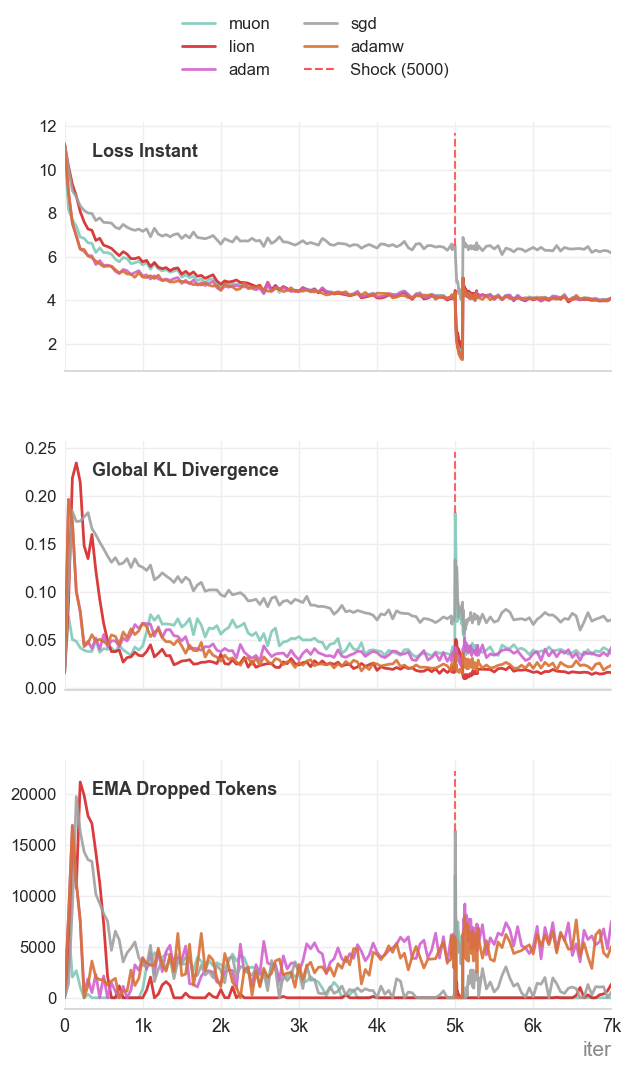

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# --- CONFIGURATION DU STYLE GRAPHIQUE (POLICES AGRANDIES) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.size": 13,                # Augmenté
        "axes.labelsize": 15,           # Augmenté
        "axes.titlesize": 16,           # Augmenté
        "xtick.labelsize": 13,          # Augmenté
        "ytick.labelsize": 12,          # Augmenté
        "grid.color": "#EEEEEE",
        "axes.edgecolor": "#FFFFFF",
    }
)

# Palette de couleurs d'origine avec SGD en gris discret
WANDB_COLORS = {
    "muon": "#82C9B9",
    "lion": "#D62728",
    "adam": "#D162CE",
    "sgd": "#A0A0A0",
    "adamw": "#D87034",
}

SHOCK_ITER = 5000

def plot_e1_metrics_final_clean(dossier_data, nom_fichier_sortie):
    files_and_metrics = [
        {"file": "E1_loss_instant.csv", "substring": "loss", "title": "Loss Instant"},
        {"file": "E1_global_kl.csv", "substring": "kl_divergence", "title": "Global KL Divergence"},
        {"file": "E1_EMA_Dropped_tokens.csv", "substring": "Dropped_tokens", "title": "EMA Dropped Tokens"}
    ]

    optimizers = ["muon", "lion", "adam", "sgd", "adamw"]

    # Largeur réduite de 8 à 6.5 pour un rendu plus compact horizontalement
    fig, axes = plt.subplots(len(files_and_metrics), 1, figsize=(6.5, 11), sharex=True)

    legend_elements_added = {}

    # 1. Boucle sur les 3 fichiers/métriques
    for i, item in enumerate(files_and_metrics):
        ax = axes[i]
        csv_path = os.path.join(dossier_data, item["file"])

        if not os.path.exists(csv_path):
            print(f"Attention : Fichier manquant {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        x_col = "iter"
        if x_col not in df.columns:
            continue

        # Titre du sous-graphique décalé à droite
        ax.text(0.05, 0.88, item["title"], transform=ax.transAxes,
                fontweight='bold', color='#333333', ha='left', va='center')

        max_y_at_shock = -np.inf # Initialisation pour stocker le maximum

        # Tracé des courbes
        for col in df.columns:
            if item["substring"].lower() in col.lower() and not (col.endswith("__MIN") or col.endswith("__MAX")):
                run_name = col.split(" - ")[0] if " - " in col else col
                clean_label = run_name.replace("env1_", "").replace("env2_", "").replace("env3_", "")
                clean_label = clean_label.split("_2026")[0].split("_shock")[0].split("_5000")[0]

                if clean_label in optimizers:
                    plot_data = df[[x_col, col]].dropna()
                    if not plot_data.empty:
                        # Mettre à jour la valeur max de Y à SHOCK_ITER pour ce fichier
                        val_at_shock = plot_data.loc[plot_data[x_col] == SHOCK_ITER, col].values
                        if val_at_shock.size > 0:
                            max_y_at_shock = max(max_y_at_shock, val_at_shock[0])

                        lbl = clean_label if clean_label not in legend_elements_added else None
                        if lbl:
                            legend_elements_added[clean_label] = True

                        ax.plot(
                            plot_data[x_col],
                            plot_data[col],
                            label=lbl,
                            color=WANDB_COLORS[clean_label],
                            linestyle="-",
                            linewidth=2.0,
                            alpha=0.9
                        )

        # --- AJOUT DE LA MARQUE DU SHOCK PERSONNALISÉE ---
        if max_y_at_shock != -np.inf:
            curr_ylim = ax.get_ylim()
            # La marque démarre du point le plus haut et s'étend jusqu'au haut de l'axe actuel
            ax.vlines(x=SHOCK_ITER, ymin=max_y_at_shock, ymax=curr_ylim[1],
                      color="#FF5252", linestyle="--", linewidth=1.5, alpha=0.9)
        else:
             # Fallback si l'itération n'est pas trouvée (ne devrait pas arriver ici)
             ax.axvline(x=5000, color="#FF5252", linestyle="--", linewidth=1.5, alpha=0.9, zorder=0)

        # --- LOOK & FEEL ---
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=False)
        ax.spines['bottom'].set_color('#D3D3D3')
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(axis='both', which='both', length=0, pad=6)

        ax.ticklabel_format(axis='y', style='plain')

    # Ajout du Shock pour la légende globale
    axes[0].plot([], [], color="#FF5252", linestyle="--", linewidth=1.5, label="Shock (5000)")

    # --- CONFIGURATION DE L'AXE X DE FIN ---
    ax_last = axes[-1]
    ax_last.set_xlabel("iter", loc="right", color="#888888")
    ax_last.set_xlim(0, 7000)
    ax_last.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, loc: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
    )

    # --- LÉGENDE COMPACTE ET PORTIONS DE TEXTE PLUS GRANDES ---
    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=2,
        frameon=False,
        fontsize=12 # Police de la légende augmentée
    )

    # Ajustements géométriques
    plt.tight_layout(rect=[0, 0, 1, 0.89])
    plt.subplots_adjust(hspace=0.28)

    plt.savefig(nom_fichier_sortie, dpi=300)
    print(f"Graphique compact mis à jour sauvegardé sous : {nom_fichier_sortie}")
    plt.show()

# --- EXÉCUTION ---
if __name__ == "__main__":
    # Assurez-vous d'avoir une variable d'environnement ou le bon chemin ici
    dossier_des_csv = os.environ.get("DATA_DIR", "./EMA/DOSSIER")
    nom_image_sortie = "E1_global_metrics.png"

    # Pour tester, vous devez avoir les fichiers dans le dossier spécifié.
    # Si les fichiers n'existent pas, le code ne tracera rien.
    plot_e1_metrics_final_clean(dossier_des_csv, nom_image_sortie)